# AI Fashion Forecasting — Trend Intelligence Pipeline

This notebook presents an **end-to-end machine learning system** designed to forecast fashion trend momentum using quantitative signals commonly analyzed by fashion brands and trend teams.

Rather than focusing on a single algorithm, this project evaluates **multiple modeling approaches** to understand how different techniques capture trend dynamics, seasonality, and non-linear consumer behavior.

### What this project does
- Constructs a structured fashion trend dataset from measurable signals
- Preprocesses categorical and numerical features for modeling
- Trains and compares:
  - Linear Regression
  - Ridge Regression
  - Decision Tree Regression
  - Neural Network (MLP)
- Evaluates performance using **MAE, RMSE, and R²**
- Visualizes results to support model selection decisions

This workflow mirrors how real-world teams prototype and validate forecasting models before deploying them on proprietary data sources.




In [12]:
# 1) Imports + Project Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

# Repo-aware paths (assumes notebook is inside /notebooks)
REPO_ROOT = Path("..").resolve()
DATA_RAW_DIR = REPO_ROOT / "data" / "raw"
DATA_PROC_DIR = REPO_ROOT / "data" / "processed"
IMG_DIR = REPO_ROOT / "images"

DATA_RAW_DIR.mkdir(parents=True, exist_ok=True)
DATA_PROC_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)


Repo root: /Users/shivaniuikey


## 2) Trend Signal Dataset

The dataset represents how fashion organizations internally quantify trend momentum using a combination of behavioral, economic, and contextual signals.

Each row corresponds to a trend observation for a given time period, category, and region.

### Feature overview

**Behavioral & Demand Signals**
- `social_buzz` — normalized measure of social media engagement and mentions
- `search_interest` — consumer search demand on a 0–100 scale
- `influencer_posts` — volume of creator-driven content

**Market & Brand Signals**
- `price_index` — relative pricing pressure of trend-related items
- `sustainability_score` — sustainability alignment of the trend

**Contextual Signals**
- `season` — winter / spring / summer / fall
- `category` — fashion segment (streetwear, luxury, athleisure, etc.)
- `region` — geographic market

### Target Variable
- `trend_score (0–100)` — a composite **trend momentum index** representing overall trend strength, adoption, and growth potential.

This target simulates how brands rank trends internally to guide design, inventory, and marketing decisions.



In [13]:
# 2) Trend Signal Dataset Builder
# This constructs a structured trend intelligence dataset from measurable signals.

def build_fashion_trend_dataset(n: int = 1800, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    # Time
    years = rng.integers(2017, 2026, size=n)
    months = rng.integers(1, 13, size=n)

    seasons = np.select(
        [
            np.isin(months, [12, 1, 2]),
            np.isin(months, [3, 4, 5]),
            np.isin(months, [6, 7, 8]),
            np.isin(months, [9, 10, 11]),
        ],
        ["winter", "spring", "summer", "fall"],
    )

    # Trend taxonomy
    categories = np.array([
        "streetwear", "athleisure", "luxury", "formal",
        "denim", "sustainable", "vintage"
    ])
    category = rng.choice(categories, size=n, p=[0.18, 0.16, 0.14, 0.10, 0.14, 0.16, 0.12])

    regions = np.array(["NA", "EU", "APAC", "LATAM"])
    region = rng.choice(regions, size=n, p=[0.35, 0.28, 0.25, 0.12])

    # Signals (features)
    social_buzz = rng.normal(0, 1.0, size=n)                       # normalized “buzz” signal
    search_interest = np.clip(rng.normal(50, 15, size=n), 0, 100)   # demand signal (0–100)
    influencer_posts = np.clip(rng.poisson(12, size=n) + rng.normal(0, 2, size=n), 0, None)
    price_index = np.clip(rng.normal(100, 8, size=n), 70, 140)
    sustainability_score = np.clip(rng.normal(0.55, 0.18, size=n), 0, 1)
    trend_momentum = rng.normal(0, 1, size=n)                        # acceleration proxy

    # Category + season + region effects (to simulate realistic adoption patterns)
    season_effect = {"winter": -2.0, "spring": 1.5, "summer": 2.5, "fall": 0.5}
    cat_effect = {
        "streetwear": 3.0, "athleisure": 2.0, "luxury": -0.5, "formal": -2.5,
        "denim": 0.5, "sustainable": 2.2, "vintage": 1.2
    }
    region_effect = {"NA": 1.0, "EU": 0.4, "APAC": 0.8, "LATAM": -0.2}

    # Seasonal cyclic components (captures yearly pattern)
    month_sin = np.sin(2 * np.pi * months / 12)
    month_cos = np.cos(2 * np.pi * months / 12)

    # Trend Heat Score (0–100): an internal “trend intelligence” index
    base_score = (
        45
        + 8.0 * social_buzz
        + 0.35 * search_interest
        + 0.9 * influencer_posts
        - 0.25 * (price_index - 100)
        + 12.0 * sustainability_score
        + 5.0 * trend_momentum
        + np.vectorize(season_effect.get)(seasons)
        + np.vectorize(cat_effect.get)(category)
        + np.vectorize(region_effect.get)(region)
        # non-linear interactions (models should learn these differently)
        + 6.0 * (month_sin * (category == "streetwear"))
        + 4.0 * (month_cos * (category == "sustainable"))
    )

    noise = rng.normal(0, 8.0, size=n)
    trend_score = np.clip(base_score + noise, 0, 100)

    return pd.DataFrame({
        "year": years,
        "month": months,
        "season": seasons,
        "category": category,
        "region": region,
        "social_buzz": social_buzz,
        "search_interest": search_interest,
        "influencer_posts": influencer_posts,
        "price_index": price_index,
        "sustainability_score": sustainability_score,
        "trend_momentum": trend_momentum,
        "trend_score": trend_score
    })

df = build_fashion_trend_dataset(n=1800, seed=SEED)
df.head()

,year,month,season,category,region,social_buzz,search_interest,influencer_posts,price_index,sustainability_score,trend_momentum,trend_score
0,2017,1,winter,denim,NA,-0.661157,67.718401,9.192983,86.072681,0.296114,-1.006828,61.941764
1,2023,6,summer,denim,NA,-1.845879,15.819665,14.768926,105.419199,0.649252,0.147849,46.892595
2,2022,6,summer,streetwear,EU,0.123309,58.840258,9.644625,115.847091,0.296490,-1.295348,68.676674
3,2020,4,spring,denim,NA,-0.470874,44.991728,5.315533,87.059077,0.782800,0.514340,71.289699
4,2020,2,winter,denim,LATAM,-0.440089,36.315228,11.950112,92.396577,0.642478,-0.977664,70.120637


In [14]:

raw_path = DATA_RAW_DIR / "fashion_trends.csv"
df.to_csv(raw_path, index=False)

raw_path, df.shape



(PosixPath('/Users/shivaniuikey/data/raw/fashion_trends.csv'), (1800, 12))

## 3) Quick EDA 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,1800.0,NaN,NaN,NaN,2021.03,2.583393,2017.0,2019.0,2021.0,2023.0,2025.0
month,1800.0,NaN,NaN,NaN,6.475556,3.459037,1.0,3.0,6.0,10.0,12.0
season,1800,4,spring,486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1800,7,streetwear,335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1800,4,NA,686,NaN,NaN,NaN,NaN,NaN,NaN,NaN
social_buzz,1800.0,NaN,NaN,NaN,0.043468,1.024678,-4.389115,-0.624407,0.010856,0.734682,3.208161
search_interest,1800.0,NaN,NaN,NaN,49.819694,14.66259,0.0,40.509472,49.682823,59.532752,100.0
influencer_posts,1800.0,NaN,NaN,NaN,11.96439,4.028856,0.0,9.252975,11.958872,14.646503,27.911122
price_index,1800.0,NaN,NaN,NaN,100.16761,8.014355,73.941059,94.665868,100.022841,105.534367,125.601944
sustainability_score,1800.0,NaN,NaN,NaN,0.557107,0.177271,0.032277,0.435704,0.560384,0.677864,1.0


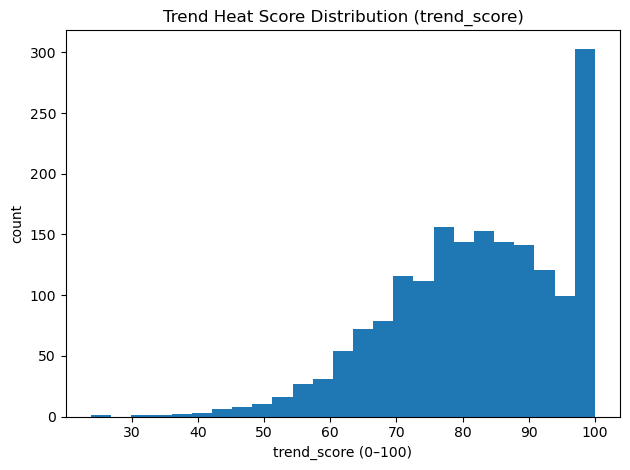

<Figure size 640x480 with 0 Axes>

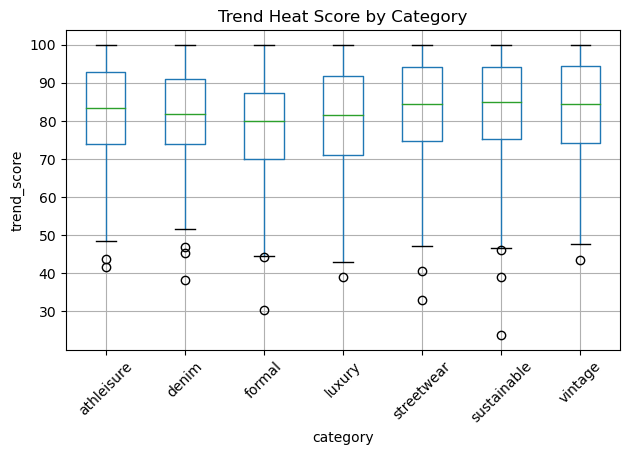

In [15]:
# 3) Quick EDA (Trend Intelligence Snapshot)

display(df.describe(include="all").T.head(20))

plt.figure()
plt.hist(df["trend_score"], bins=25)
plt.title("Trend Heat Score Distribution (trend_score)")
plt.xlabel("trend_score (0–100)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# Trend Score by Category (simple overview)
plt.figure()
df.boxplot(column="trend_score", by="category", rot=45)
plt.title("Trend Heat Score by Category")
plt.suptitle("")
plt.xlabel("category")
plt.ylabel("trend_score")
plt.tight_layout()
plt.show()



## 4) Preprocessing

We one-hot encode categorical columns (season/category/region) and split into train/test.


In [16]:
# 4) Preprocessing: One-hot encode + split

cat_cols = ["season", "category", "region"]
df_proc = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_proc.drop(columns=["trend_score"])
y = df_proc["trend_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# Save processed artifacts
df_proc.to_csv(DATA_PROC_DIR / "fashion_trends_processed.csv", index=False)
X_train.to_csv(DATA_PROC_DIR / "X_train.csv", index=False)
X_test.to_csv(DATA_PROC_DIR / "X_test.csv", index=False)
y_train.to_csv(DATA_PROC_DIR / "y_train.csv", index=False, header=True)
y_test.to_csv(DATA_PROC_DIR / "y_test.csv", index=False, header=True)

X_train.shape, X_test.shape



((1440, 20), (360, 20))

## 5) Train Models (Regression, Decision Tree, Neural Network)

We’ll compare:
- Linear Regression (baseline)
- Ridge Regression (regularized linear)
- Decision Tree Regressor (non-linear)
- MLPRegressor (neural network) with scaling


In [17]:
# 5) Model Training & Comparison

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=SEED),
    "DecisionTree": DecisionTreeRegressor(max_depth=8, random_state=SEED),
    "NeuralNet(MLP)": Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            random_state=SEED,
            max_iter=700,
            early_stopping=True,
        )),
    ]),
}

def evaluate_regression(y_true, y_pred) -> dict:
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "R2": r2_score(y_true, y_pred),
    }

results = []
preds_store = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds_store[name] = preds

    metrics = evaluate_regression(y_test, preds)
    metrics["model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
results_df


,MAE,RMSE,R2,model
0,6.129450,7.667068,0.642380,Ridge
1,6.131093,7.668189,0.642275,LinearRegression
2,6.618752,8.217026,0.589236,NeuralNet(MLP)
3,8.429987,10.623059,0.313465,DecisionTree


In [18]:
# Save model comparison results to repo root
results_path = REPO_ROOT / "model_results.csv"
results_df.to_csv(results_path, index=False)

results_path


PosixPath('/Users/shivaniuikey/model_results.csv')

## 6) Visualize Model Performance

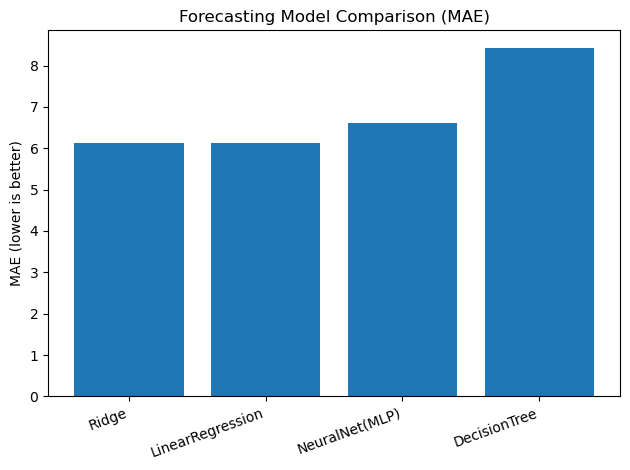

PosixPath('/Users/shivaniuikey/images/model_comparison.png')

In [19]:
# 6) Visualize Model Performance (MAE)

plt.figure()
x = np.arange(len(results_df))
plt.bar(x, results_df["MAE"].values)
plt.xticks(x, results_df["model"].values, rotation=20, ha="right")
plt.ylabel("MAE (lower is better)")
plt.title("Forecasting Model Comparison (MAE)")
plt.tight_layout()

out = IMG_DIR / "model_comparison.png"
plt.savefig(out, dpi=200)
plt.show()

out



## 7) Predictions vs Actual for the Best Model

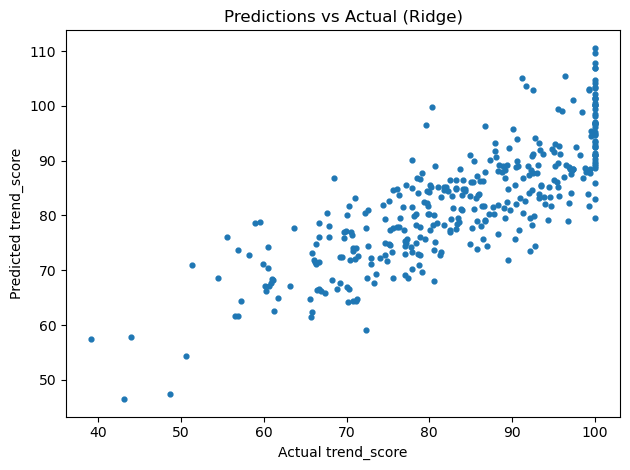

('Ridge', PosixPath('/Users/shivaniuikey/images/predictions.png'))

In [20]:
# 7) Predictions vs Actual for best model

best_model_name = results_df.loc[0, "model"]
best_preds = preds_store[best_model_name]

plt.figure()
plt.scatter(y_test.values, best_preds, s=12)
plt.xlabel("Actual trend_score")
plt.ylabel("Predicted trend_score")
plt.title(f"Predictions vs Actual ({best_model_name})")
plt.tight_layout()

out = IMG_DIR / "predictions.png"
plt.savefig(out, dpi=200)
plt.show()

best_model_name, out



## “Trend Drivers” — which signals correlate most with trend_score?

In [21]:


numeric_cols = [
    "social_buzz", "search_interest", "influencer_posts",
    "price_index", "sustainability_score", "trend_momentum",
    "month", "year"
]

corr = df[numeric_cols + ["trend_score"]].corr(numeric_only=True)["trend_score"].drop("trend_score")
drivers = corr.abs().sort_values(ascending=False)

drivers_df = pd.DataFrame({
    "feature": drivers.index,
    "abs_corr_with_trend_score": drivers.values,
    "signed_corr": corr.loc[drivers.index].values
})

drivers_df


,feature,abs_corr_with_trend_score,signed_corr
0,social_buzz,0.551839,0.551839
1,search_interest,0.340872,0.340872
2,trend_momentum,0.335688,0.335688
3,influencer_posts,0.247867,0.247867
4,price_index,0.154939,-0.154939
5,sustainability_score,0.150042,0.150042
6,year,0.026601,-0.026601
7,month,0.012550,0.012550


## Conclusion

This project demonstrates how machine learning can be used to model and forecast **fashion trend momentum** by translating complex, real-world signals into a structured analytical pipeline.

By constructing a trend intelligence dataset and evaluating multiple modeling approaches, this notebook highlights several key insights:

- **Model comparison matters**: Linear and regularized regression models provided strong baselines, while more complex models such as decision trees and neural networks introduced flexibility in capturing non-linear relationships. Selecting a model based on empirical metrics (MAE, RMSE, R²) proved more effective than assuming complexity alone leads to better performance.
- **Feature design drives results**: Signals such as social buzz, search interest, sustainability alignment, and seasonal patterns played a significant role in explaining trend strength, reinforcing the importance of thoughtful feature engineering in forecasting problems.
- **Interpretability vs. complexity tradeoffs**: While neural networks can capture richer interactions, simpler models offered competitive performance with greater interpretability—an important consideration in business-driven decision making.
- **Visualization enhances communication**: Performance comparisons and prediction plots made it easier to communicate model behavior and confidence to non-technical stakeholders.

Overall, this project mirrors how fashion and retail analytics teams prototype forecasting systems before deploying them on proprietary data. The workflow is intentionally modular, making it easy to extend toward time-series forecasting, hyperparameter tuning, or interactive dashboards.

Future iterations could integrate real-time trend feeds, incorporate cross-validation and model tuning, and deploy the forecasting system as a live decision-support tool for designers, merchandisers, and marketers.

